Take Home Assignment 02: Liquid Level

1. Analyzing the liquid level of a vessel will be studied in this assignment
2. How to utilize background subtraction is demonstrated in the notebook
3. How to use subsequent thresholding and contour analysis is also demonstrated
4. The student's task is to implement the demonstrated techniques to obtain a liquid level plot for the entirety of the video

Notes:
It is advised to go over the opencv documentation for the following functions

cv2.threshold  :  https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html




Student has to deliver:
1. Plot of the liquid level.
2. A brief note on what the student understood by reading the section on Otsu's threholding method.
3. 2 examples of probable erroraneous liquid level readings, when using Otsu's method. Show with annoted images.
4. A brief description on the final algorithm developed by the student.


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

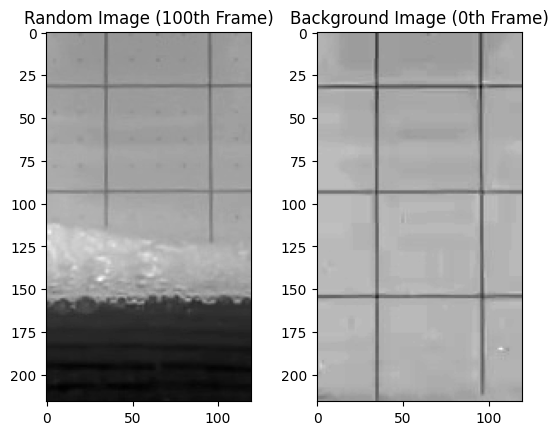

In [6]:
# Importing Demo Images
img_r = cv2.imread('demo2_images/liquid_frame100.jpg', 0)
img_b = cv2.imread('demo2_images/liquid_frame000.jpg', 0)

# Display the images
plt.subplot(121), plt.imshow(img_r, cmap='gray'), plt.title('Random Image (100th Frame)')
plt.subplot(122), plt.imshow(img_b, cmap='gray'), plt.title('Background Image (0th Frame)')
plt.show()

Method 1 : Background Subtraction

Threshold Value: 50.0
Contour 0 Area: 6826.0
Contour 1 Area: 0.0
Contour 2 Area: 0.0
Total Area: 25920
Percentage: 26.3 %


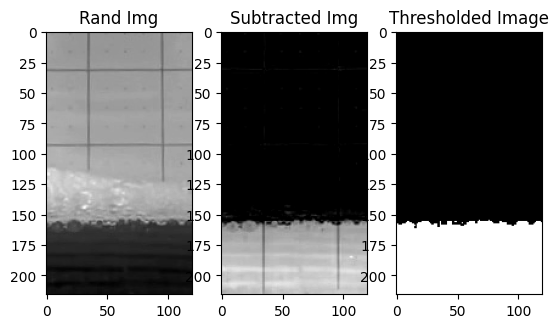

In [3]:
# Subtracting the images
img_sub = cv2.subtract(img_b, img_r)

# Thresholding the image, to obtain binary image
ret, img_sub_thresh = cv2.threshold(img_sub, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# Print the used threshold value
print('Threshold Value:', ret)

# Find contours in the image
contours, hierarchy = cv2.findContours(img_sub_thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Sort the contours by size in descending order
contours = sorted(contours, key=lambda x: cv2.contourArea(x), reverse=True)
# Print the contour areas
for i in range(len(contours)):
    print('Contour', i, 'Area:', cv2.contourArea(contours[i]))

# Find the area of the whole image
rows, cols = img_sub_thresh.shape
total_area = rows * cols
print('Total Area:', total_area)

# Calculate the percentage of the largest contour area, rounded to 1 decimal point
percentage = round((cv2.contourArea(contours[0]) / total_area) * 100, 1)
print('Percentage:', percentage, '%')

# Display img_r , img_sub, img_sub_thresh side by side using plt
plt.subplot(131), plt.imshow(img_r, cmap='gray'), plt.title('Rand Img')
plt.subplot(132), plt.imshow(img_sub, cmap='gray'), plt.title('Subtracted Img')
plt.subplot(133), plt.imshow(img_sub_thresh, cmap='gray'), plt.title('Thresholded Image')
plt.show()

How to read video files

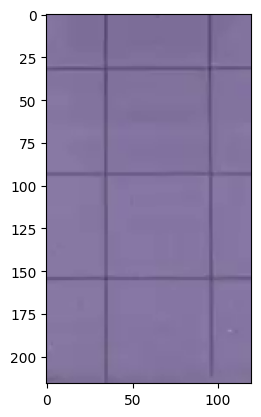

In [4]:
# Reading frames from a video
cap = cv2.VideoCapture('demo2_images/liquidVideo.mp4')
ret, frame1 = cap.read()

# Displaying the first frame using plt
plt.imshow(frame1)
plt.show()



## Answers

1. Plot of the liquid level.

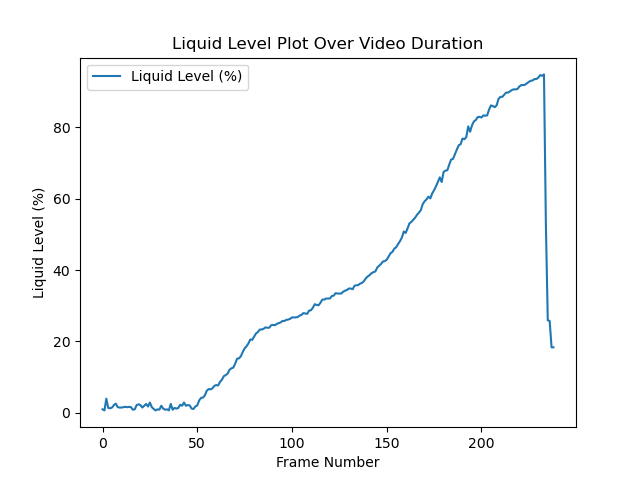

2. A brief note on what the student understood by reading the section on Otsu's threholding method.

Global vs. Otsu's Thresholding: In traditional global thresholding, a fixed threshold value is chosen arbitrarily to convert an image to a binary form. Otsu's method, on the other hand, automatically calculates the optimal threshold value based on the image histogram, removing the need for arbitrary selection.

Bimodal Histogram: Otsu's method works best for images that have two distinct intensity values, forming a bimodal histogram with two peaks. The optimal threshold is determined by finding a value that lies between these peaks, effectively separating the foreground and background.

cv.threshold() with cv.THRESH_OTSU: The Otsu thresholding method is implemented using the cv.threshold() function in OpenCV, where the cv.THRESH_OTSU flag is passed. This flag instructs the algorithm to compute the optimal threshold value automatically from the image histogram.

As an example showing the effectiveness of Otsu's thresholding. In cases with noise, applying a Gaussian filter before Otsu's thresholding improves the result, demonstrating how noise filtering can enhance the performance of Otsu's method.

3. 2 examples of probable erroraneous liquid level readings, when using Otsu's method. Show with annoted images.

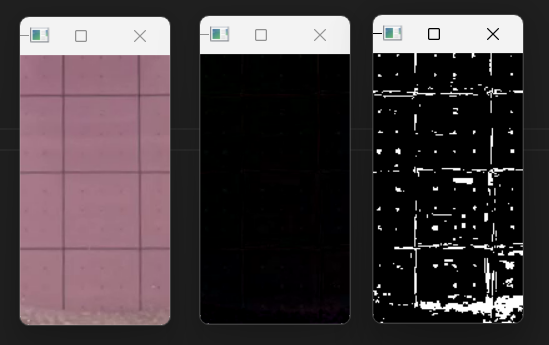


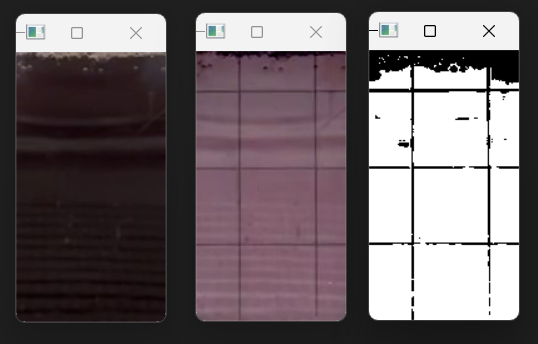

4. A brief description on the final algorithm developed by the student.


Video Loading and Background Capture: The video file is loaded using OpenCV’s cv2.VideoCapture(). The first frame is used as the reference background for comparing subsequent frames to detect the liquid level.


Frame Processing: For each frame in the video:

The algorithm subtracts the current frame from the background, highlighting any changes (i.e., liquid level variations).
The subtracted image is converted to grayscale and thresholded using Otsu's method, which automatically determines the optimal threshold for binarizing the image.
Contour Detection: The algorithm detects the contours in the thresholded binary image using cv2.findContours(). The contours are sorted by size, and the largest contour is assumed to represent the liquid.


Liquid Level Calculation: The area of the largest contour is calculated, and the percentage of the liquid level in relation to the total image area is computed. This percentage is then appended to a list for later plotting.


Visualization: The original video frame, the subtracted image, and the thresholded image are displayed using OpenCV’s imshow(). The liquid level is also printed for each frame.


Plotting: After processing all frames, the algorithm plots the liquid level over time (in terms of frame numbers) using Matplotlib, displaying a graph of liquid level percentage versus frame number.

In [ ]:
import cv2
import matplotlib.pyplot as plt

def process_video_and_plot_liquid_level(video_path):
    """
    Processes a video to calculate the liquid level in each frame,
    and plots the liquid level over time.

    Parameters:
    - video_path (str): Path to the input video file.
    """
    # Open the video file
    cap = cv2.VideoCapture(video_path)

    # Read the first frame to use as the background
    ret, background = cap.read()

    # List to store the liquid level percentages for plotting
    liquid_levels = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Subtract the background from the current frame
        img_sub = cv2.subtract(background, frame)

        # Convert the subtracted image to grayscale
        img_sub_gray = cv2.cvtColor(img_sub, cv2.COLOR_BGR2GRAY)

        # Apply thresholding to obtain a binary image
        ret, img_sub_thresh = cv2.threshold(img_sub_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Print the used threshold value
        print(f'Threshold Value: {ret}')

        # Find contours in the binary image
        contours, _ = cv2.findContours(img_sub_thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

        # Sort contours by area in descending order
        contours = sorted(contours, key=cv2.contourArea, reverse=True)

        # Calculate the total area of the image
        total_area = img_sub_thresh.size
        print(f'Total Area: {total_area}')

        # Calculate the percentage of the largest contour area in the image
        largest_contour_area = cv2.contourArea(contours[0]) if contours else 0
        percentage = round((largest_contour_area / total_area) * 100, 1)
        liquid_levels.append(percentage)

        # Print the percentage of liquid level
        print(f'Percentage: {percentage} %')

        # Display the original frame, subtracted image, and thresholded image
        cv2.imshow('Video', frame)
        cv2.imshow('Sub', img_sub)
        cv2.imshow('Sub Thresh', img_sub_thresh)

        # Exit the loop if 'q' is pressed
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

    # Plot the liquid level over time (video frames)
    plt.plot(liquid_levels, label='Liquid Level (%)')
    plt.xlabel('Frame Number')
    plt.ylabel('Liquid Level (%)')
    plt.title('Liquid Level Plot Over Video Duration')
    plt.legend()
    plt.show()

# Example usage:
video_path = 'demo2_images/liquidVideo.mp4'
process_video_and_plot_liquid_level(video_path)